<a href="https://colab.research.google.com/github/srijanisinha/Olist-AB-Testing-Project/blob/main/App_Game_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
from google.colab import drive

# This tells Colab to unlock and open your Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Tell Python where the file is in your Drive
file_path = '/content/drive/MyDrive/olist_sales/olist_marketing_qualified_leads_dataset.csv'

# Open the file
real_data = pd.read_csv(file_path)

print("Data loaded successfully from Google Drive!")
# Show the top 5 rows
real_data.head()

Data loaded successfully from Google Drive!


,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


## Analyze the Real Data (Where do people come from?)

--- WHERE OUR USERS CAME FROM ---
origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
Name: mql_id, dtype: int64


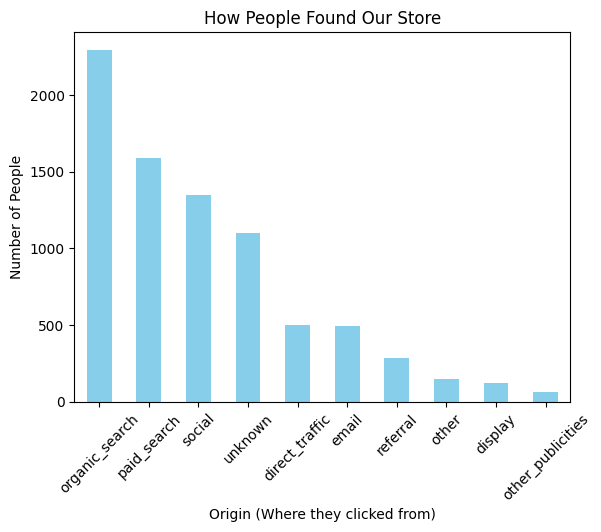

In [17]:
# Count how many people came from different places (the 'origin' column)
traffic_sources = real_data.groupby('origin')['mql_id'].count().sort_values(ascending=False)

print("--- WHERE OUR USERS CAME FROM ---")
print(traffic_sources)

# Let's draw a bar chart to show the boss!
traffic_sources.plot(kind='bar', color='skyblue')

# Add labels to the chart
plt.title('How People Found Our Store')
plt.xlabel('Origin (Where they clicked from)')
plt.ylabel('Number of People')
plt.xticks(rotation=45) # Tilts the words so they fit nicely

# Show the chart!
plt.show()

## A/B testing

A/B TEST RESULTS
Group A (Old Screen) Sales: 53
Group B (New Screen) Sales: 79


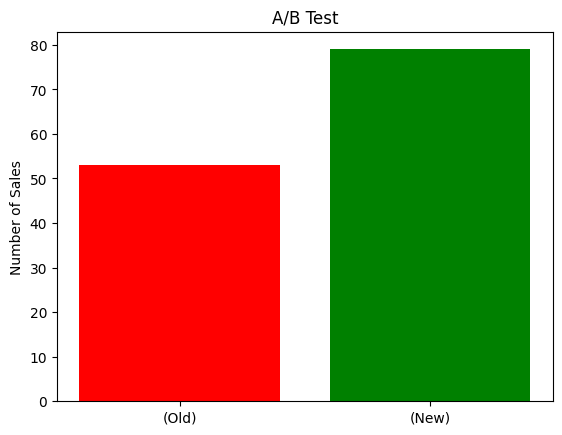

In [18]:
# We flip a digital coin for 1,000 users!

# Group A (Old Checkout) - 10% chance of buying
group_a = np.random.binomial(n=1, p=0.10, size=500)

# Group B (New Checkout) - 15% chance of buying
group_b = np.random.binomial(n=1, p=0.15, size=500)

# Add up all the winners (people who actually bought something)
sales_a = group_a.sum()
sales_b = group_b.sum()

print("A/B TEST RESULTS")
print(f"Group A (Old Screen) Sales: {sales_a}")
print(f"Group B (New Screen) Sales: {sales_b}")

# Chart the winner!
plt.bar(['(Old)', '(New)'], [sales_a, sales_b], color=['red', 'green'])
plt.title('A/B Test')
plt.ylabel('Number of Sales')
plt.show()

## Retention

--- RETENTION OVER TIME ---
      Day  Group A % returning  Group B % returning
0   Day 1                   40                   60
1   Day 7                   20                   35
2  Day 30                    5                   10


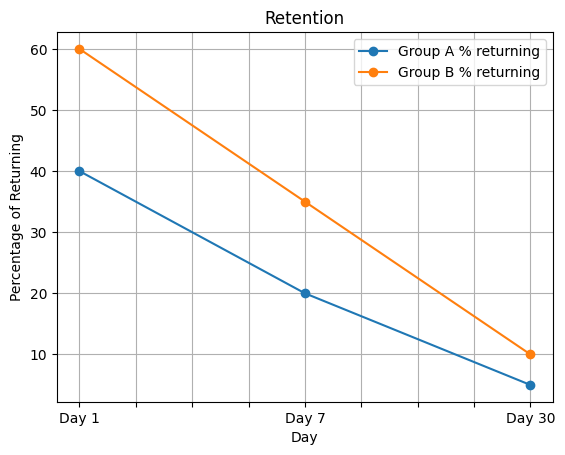

In [19]:
# Pretend data for players coming back to the store
retention_data = {
    'Day': ['Day 1', 'Day 7', 'Day 30'],
    'Group A % returning': [40, 20, 5],
    'Group B % returning': [60, 35, 10]
}
retention_df = pd.DataFrame(retention_data)

print("--- RETENTION OVER TIME ---")
print(retention_df)

# Draw a line chart to show the drop-off over 30 days
retention_df.plot(x='Day', y=['Group A % returning', 'Group B % returning'], kind='line', marker='o')
plt.title("Retention")
plt.ylabel("Percentage of Returning")
plt.grid(True) # Adds a nice grid background
plt.show()

## KPI Part

In [20]:
# --- STEP 1: Set up the total visitors ---
total_visitors_a = 500
total_visitors_b = 500

# --- STEP 2: Calculate KPI 1 (Conversion Rate) ---
# We use the 'sales_a' and 'sales_b' boxes we made in the last step!
conversion_rate_a = (sales_a / total_visitors_a) * 100
conversion_rate_b = (sales_b / total_visitors_b) * 100

# --- STEP 3: Calculate KPI 2 (The Lift) ---
lift = ((conversion_rate_b - conversion_rate_a) / conversion_rate_a) * 100

# --- STEP 4: Print the Boss's KPI Dashboard ---
print(" KEY PERFORMANCE INDICATORS ")

# The round() tool cuts off super long decimals to make it look neat (2 decimal places)
print(f"Old Screen Conversion Rate: {round(conversion_rate_a, 2)}%")
print(f"New Screen Conversion Rate: {round(conversion_rate_b, 2)}%")
print(f"Business Lift (Improvement): The new screen is {round(lift, 2)}% better!")

 KEY PERFORMANCE INDICATORS 
Old Screen Conversion Rate: 10.6%
New Screen Conversion Rate: 15.8%
Business Lift (Improvement): The new screen is 49.06% better!


In [21]:
import pandas as pd

# --- PACKING BOX 1: The A/B Test & KPIs ---
# We are taking your KPI math and turning it into a neat table
ab_test_summary = pd.DataFrame({
    'Group': ['Old Screen (Group A)', 'New Screen (Group B)'],
    'Total Players': [total_visitors_a, total_visitors_b],
    'Total Sales': [sales_a, sales_b],
    'Conversion Rate (%)': [round(conversion_rate_a, 2), round(conversion_rate_b, 2)]
})

# --- THE ROBOT FILING CABINET (ExcelWriter) ---
# This line creates a brand new Excel file directly in your Google Drive!
file_name = '/content/drive/MyDrive/Project_3_Dashboard_Data.xlsx'

with pd.ExcelWriter(file_name) as writer:

    # Put the Funnel data in Tab 1
    traffic_sources.to_frame(name='Number of People').to_excel(writer, sheet_name='1_Funnel_Data')

    # Put the A/B Test data in Tab 2
    ab_test_summary.to_excel(writer, sheet_name='2_AB_Test_KPIs', index=False)

    # Put the Retention data in Tab 3
    retention_df.to_excel(writer, sheet_name='3_Retention_Data', index=False)

print("🎉 Success! Your Excel file is ready in your Google Drive! 🎉")

🎉 Success! Your Excel file is ready in your Google Drive! 🎉


## Final Dashboard Presentation

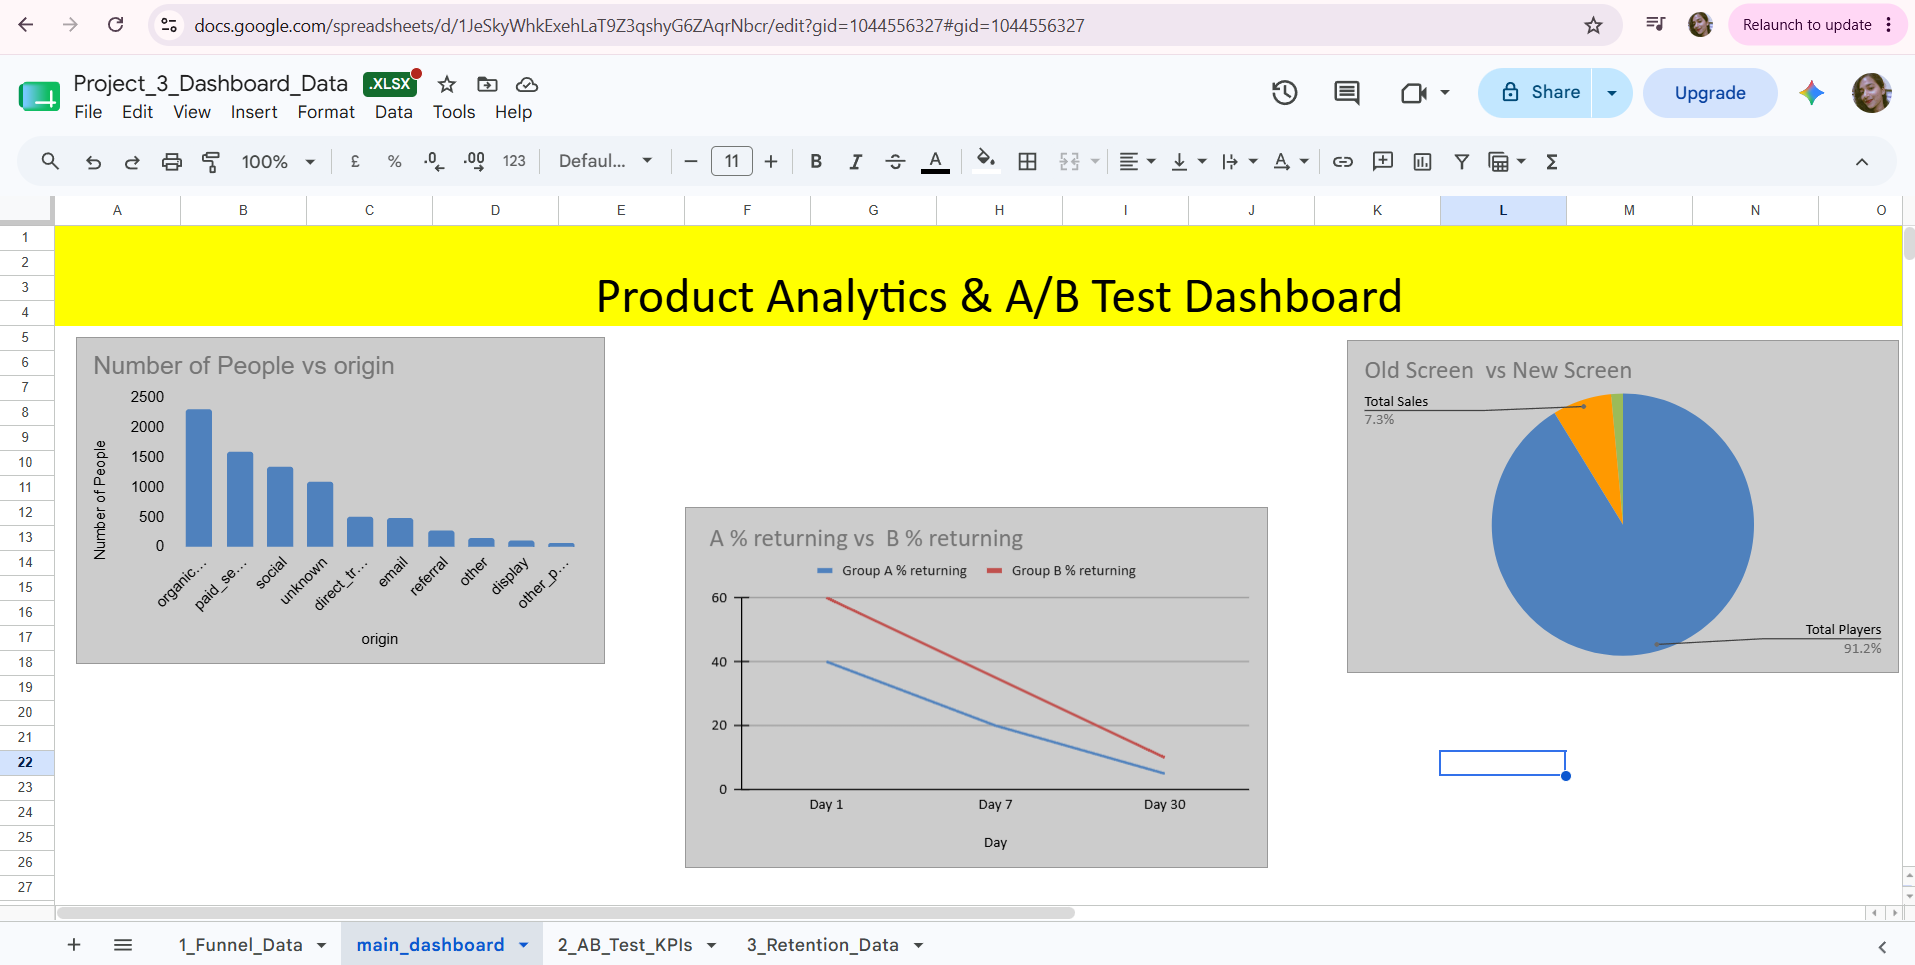